Question: Load iris data with sklearn.datasets.load_iris. Train a decision tree with this data, specifying params max_depth=4 and random_state=17 (all other arguments shall be left unchanged). Use all available 150 instances to train a tree (do not perform train/validation split). Visualize the fitted decision tree, see topic 3 for examples. Let's call a leaf in a tree pure if it contains instances of only one class. How many pure leaves are there in this tree?

pure_leaves=7


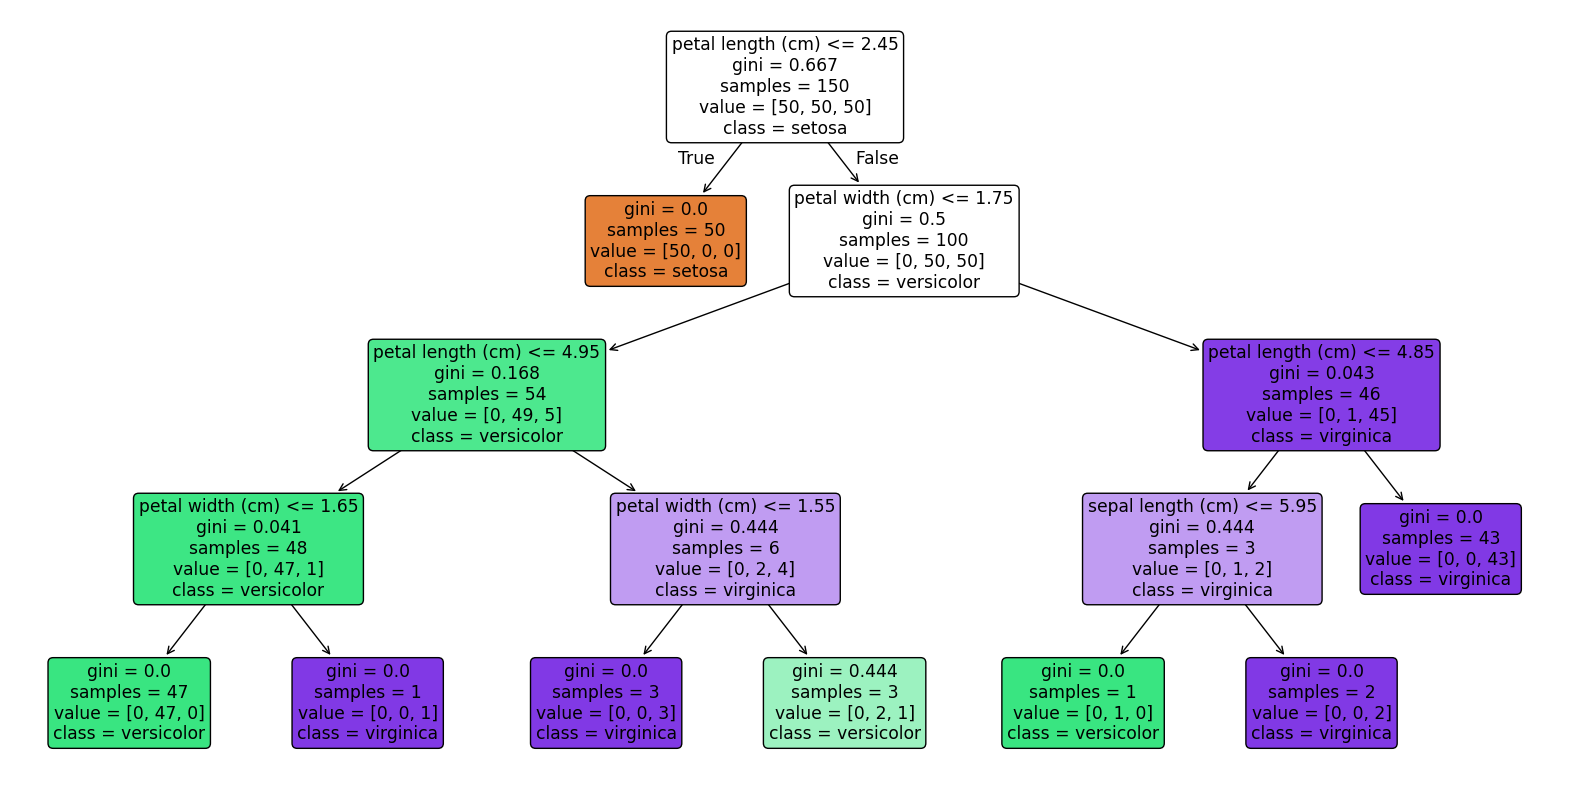

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Load data
iris = load_iris()
X, y = iris.data, iris.target

# Train decision tree
clf = DecisionTreeClassifier(max_depth=4, random_state=17)
clf.fit(X, y)

# Analyze leaves
n_nodes = clf.tree_.node_count
children_left = clf.tree_.children_left
children_right = clf.tree_.children_right
value = clf.tree_.value

pure_leaves = 0
for i in range(n_nodes):
    # Check if it is a leaf
    if children_left[i] == children_right[i]:  # children_left[i] == -1
        # Check if it is pure (only one class has non-zero count)
        counts = value[i][0]
        if sum(counts > 0) == 1:
            pure_leaves += 1

print(f"{pure_leaves=}")

# Visualize the fitted decision tree
plt.figure(figsize=(20,10))
plot_tree(clf, filled=True, feature_names=iris.feature_names, class_names=iris.target_names, rounded=True)
plt.show()